In [66]:
import numpy as np
import pandas as pd
import rasterio
import tifffile as tiff
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter
from skimage.transform import resize
from sklearn.model_selection import train_test_split
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


In [54]:

# ========== 1. Grouping Files ==========
def group_files(source_dir, output_json="grouped_files.json"):
    SOURCE_DIR = Path(source_dir)
    grouped_files = defaultdict(lambda: defaultdict(list))
    pattern = re.compile(
        r"(?P<id>C[12]_\d+_\d{8}_\d{8}_[\w-]+?)_(\d+_)?(?P<tag>CH4CM|CH4PL|CH4SR|CH4|CH4ER|ALB|FLG|META|BRW)\.(tif|png|csv|json|pdf)"
    )

    for path in SOURCE_DIR.rglob("*"):
        if path.is_file():
            match = pattern.search(path.name)
            if match:
                obs_id = match.group("id")
                tag = match.group("tag")
                grouped_files[obs_id][tag].append(str(path))

    # Flatten single-item lists
    for obs_id, tag_map in grouped_files.items():
        for tag, paths in tag_map.items():
            if len(paths) == 1:
                tag_map[tag] = paths[0]

    # Save to JSON
    def to_serializable(obj):
        if isinstance(obj, defaultdict):
            obj = {k: to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, dict):
            obj = {k: to_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            obj = [to_serializable(v) for v in obj]
        return obj

    with open(output_json, "w") as f:
        json.dump(to_serializable(grouped_files), f, indent=2)

# ========== 2. Load and Resize ==========
def load_grouped_files(json_path):
    with open(json_path, 'r') as f:
        return json.load(f)

def normalize(band):
    b = np.nan_to_num(band.astype(np.float32), nan=0.0)
    b[b < 0] = 0
    return b



def load_and_resize(path, shape=(128, 128)):
    try:
        with rasterio.open(path) as src:
            img = src.read(1).astype(np.float32)
            if img.ndim != 2:
                return None
            return resize(np.nan_to_num(img, nan=0.0), shape, anti_aliasing=True)
    except Exception:
        return None

# ========== 3. Build Dataset ==========
def build_resized_dataset(grouped_files, target_shape=(128, 128)):
    X = []
    y = []
    stats = Counter()

    for obs_id, files in grouped_files.items():
        required = ["CH4PL", "CH4SR", "CH4", "ALB", "FLG", "CH4ER"]
        if not all(k in files for k in required):
            stats["missing_required_keys"] += 1
            continue

        ch4pl_list = files["CH4PL"] if isinstance(files["CH4PL"], list) else [files["CH4PL"]]
        ch4sr_list = files["CH4SR"] if isinstance(files["CH4SR"], list) else [files["CH4SR"]]

        if len(ch4pl_list) != len(ch4sr_list):
            stats["mismatched_ch4pl_ch4sr"] += 1
            continue

        for ch4pl_path, ch4sr_path in zip(ch4pl_list, ch4sr_list):
            try:
                ch4pl = normalize(load_and_resize(ch4pl_path, shape=target_shape))
                ch4   = normalize(load_and_resize(files["CH4"], shape=target_shape))
                alb   = normalize(load_and_resize(files["ALB"], shape=target_shape))
                flg   = normalize(load_and_resize(files["FLG"], shape=target_shape))
                ch4er = normalize(load_and_resize(files["CH4ER"], shape=target_shape))


                if any(x is None for x in (ch4pl, ch4, alb, flg, ch4er)):
                    stats["bad_resize_or_load"] += 1
                    continue

                df = pd.read_csv(ch4sr_path)
                if "Q-IME [kg/hr]" not in df.columns:
                    stats["missing_qime"] += 1
                    continue

                target = float(df["Q-IME [kg/hr]"].values[0])
                for band in (ch4pl, ch4, alb, flg, ch4er):
                    band[np.isnan(band)] = 0
                for band in (ch4pl, ch4, alb, flg, ch4er):
                    band[band < 0] = 0  # remove any negative values


                img = np.stack([ch4pl, ch4, alb, flg, ch4er], axis=-1)
                X.append(img)
                y.append(target)
                stats["valid"] += 1

            except Exception:
                stats["exception"] += 1

    X = np.array(X)
    y = np.array(y)

    # NaN filtering
    print("Before NaN filter:", X.shape)
    valid_mask = ~np.isnan(X).any(axis=(1, 2, 3))
    X = X[valid_mask]
    y = y[valid_mask]
    print("After NaN filter:", X.shape)
    stats["nan_filtered"] = len(valid_mask) - valid_mask.sum()

    return X, y, stats

# ========== 4. Save Dataset ==========
def save_dataset(X, y, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



    np.save(output_dir / "X_train.npy", X_train)
    np.save(output_dir / "X_test.npy", X_test)
    np.save(output_dir / "y_train.npy", y_train)
    np.save(output_dir / "y_test.npy", y_test)

    return {
        "X_train": X_train.shape,
        "X_test": X_test.shape,
        "y_train": y_train.shape,
        "y_test": y_test.shape
    }

# ========== 5. Full Pipeline ==========
def full_pipeline(json_path, output_dir="GHGsat", target_shape=(128, 128)):
    grouped_files = load_grouped_files(json_path)
    X, y, stats = build_resized_dataset(grouped_files, target_shape=target_shape)
    shapes = save_dataset(X, y, output_dir)
    return {"dataset_shapes": shapes, "load_stats": stats}



In [55]:
results = full_pipeline("grouped_files.json")
print(results)


Before NaN filter: (302, 128, 128, 5)
After NaN filter: (302, 128, 128, 5)
{'dataset_shapes': {'X_train': (241, 128, 128, 5), 'X_test': (61, 128, 128, 5), 'y_train': (241,), 'y_test': (61,)}, 'load_stats': Counter({'valid': 302, 'nan_filtered': 0})}


In [56]:
# Load data from saved .npy files
X_train = np.load("GHGsat/X_train.npy")
X_test  = np.load("GHGsat/X_test.npy")
y_train = np.load("GHGsat/y_train.npy")
y_test  = np.load("GHGsat/y_test.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (241, 128, 128, 5)
y_train shape: (241,)


In [71]:
input_shape = X_train.shape[1:]

model = models.Sequential([
    layers.Input(shape=(128, 128, 5)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),  # Prevent overfitting
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 126, 126, 32)   │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,529 (400.50 KB)

 Trainable params: 102,337 (399.75 KB)

 Non-trainable params: 192 (768.00 B)

In [72]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 6706281.5000 - mae: 2026.1017 - val_loss: 5016511.0000 - val_mae: 1739.8561
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 5816390.0000 - mae: 1856.8384 - val_loss: 4741376.0000 - val_mae: 1663.8562
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 5900540.5000 - mae: 1809.1418 - val_loss: 4223511.5000 - val_mae: 1511.8070
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 4516213.5000 - mae: 1517.5116 - val_loss: 2970178.5000 - val_mae: 1189.5995
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - loss: 2747143.7500 - mae: 1153.4575 - val_loss: 2928835.2500 - val_mae: 1173.3484
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 2080218.2500 - mae: 1101.8448 - val_loss: 2250528.7500 - val_mae: 1139.5044
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 2480932.7500 - mae: 1253.7721 - val_loss: 1984110.7500 - val_mae: 996.3006
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - los

In [64]:
print("Any NaNs in X_train?", np.isnan(X_train).any())
print("Min/Max values:", np.min(X_train), np.max(X_train))

print("Any NaNs in y_train?", np.isnan(y_train).any())
print("Min/Max y_train:", np.min(y_train), np.max(y_train))


Any NaNs in X_train? False
Min/Max values: 0.0 5070.8364
Any NaNs in y_train? False
Min/Max y_train: 136.0 7476.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


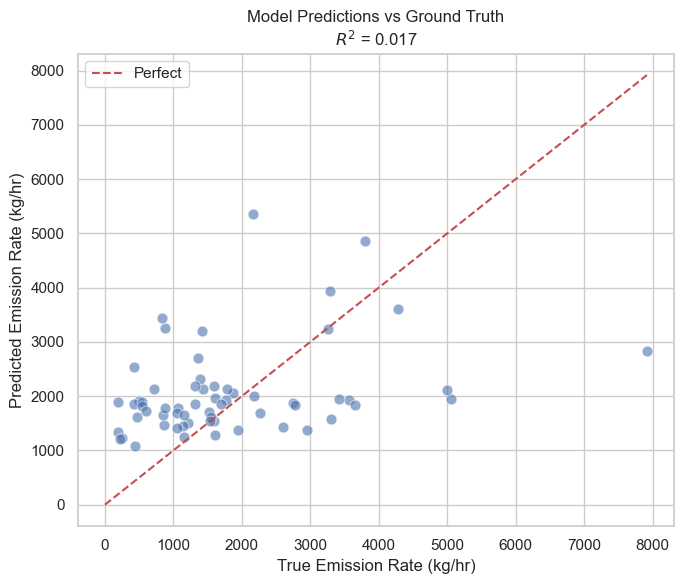

In [70]:
# Predict
y_pred = model.predict(X_test).flatten()

# Compute R²
r2 = r2_score(y_test, y_pred)

# Plot with seaborn
plt.figure(figsize=(7, 6))
sns.set(style="whitegrid")

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, s=60)
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', label='Perfect')

plt.xlabel("True Emission Rate (kg/hr)")
plt.ylabel("Predicted Emission Rate (kg/hr)")
plt.title(f"Model Predictions vs Ground Truth\n$R^2$ = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()
